Upload **bank.csv**:


Saving bank.csv to bank (1).csv
Successfully loaded data with **17** columns.
Starting **Brute Force Cleaning**...
Training **Logistic Regression**...

MARKETING CLASSIFICATION RESULTS
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1175
           1       0.78      0.79      0.79      1058

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233



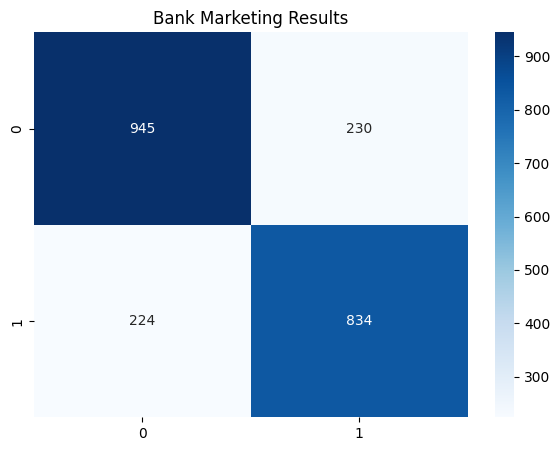

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. UPLOAD ---
print("Upload **bank.csv**:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# --- 2. THE FIX: SMART LOADING ---
try:
    # Try loading with semicolon first (Standard for Bank Marketing)
    df = pd.read_csv(file_name, sep=';')

    # If it only found 1 column, it's probably actually comma-separated
    if df.shape[1] <= 1:
        df = pd.read_csv(file_name, sep=',')

    print(f"Successfully loaded data with **{df.shape[1]}** columns.")

    # --- 3. BRUTE FORCE CLEANING & ENCODING ---
    print("Starting **Brute Force Cleaning**...")
    df = df.dropna(axis=1, how='all').dropna(axis=0, how='any')

    le = LabelEncoder()
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = le.fit_transform(df[col].astype(str))

    # --- 4. MODELING ---
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    print("Training **Logistic Regression**...")
    model = LogisticRegression(class_weight='balanced', solver='liblinear')
    model.fit(X_train, y_train)

    # --- 5. RESULTS ---
    y_pred = model.predict(X_test)
    print("\n" + "="*40)
    print("MARKETING CLASSIFICATION RESULTS")
    print("="*40)
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Visualization
    plt.figure(figsize=(7, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Bank Marketing Results')
    plt.show()

except Exception as e:
    print(f"Error: {e}")